In [1]:
# Cell 1 — Imports and connection
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import psycopg2
conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()
print("Connected.")

Connected.


In [2]:
# Cell 2 — Schema introspection
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'int'
    AND table_name = 'int_game_team_features'
    ORDER BY ordinal_position
""")
for row in cur.fetchall():
    print(row)

('game_id', 'bigint')
('season', 'integer')
('week', 'integer')
('game_date', 'date')
('team_name', 'text')
('opponent', 'text')
('points_scored', 'integer')
('points_allowed', 'integer')
('win', 'integer')
('off_epa_per_play', 'numeric')
('def_epa_per_play_allowed', 'numeric')
('close_game_epa_per_play', 'numeric')
('close_game_play_count', 'bigint')
('close_game_def_epa_per_play', 'numeric')
('close_game_def_play_count', 'bigint')
('game_script', 'text')
('game_script_avg_margin', 'numeric')
('last3_off_epa_avg', 'numeric')
('last3_win_pct', 'numeric')
('last3_points_scored_avg', 'numeric')
('last3_def_epa_avg', 'numeric')
('last3_points_allowed_avg', 'numeric')
('days_since_last_game', 'integer')
('opp_sp_rating_at_game_time', 'numeric')
('pregame_elo', 'numeric')
('opponent_pregame_elo', 'numeric')
('postgame_elo', 'numeric')
('excitement_index', 'numeric')


In [3]:
# Cell 3 — Load candidate features
candidates = pd.read_csv(os.path.expanduser("~/cfb-analytics/artifacts/candidate_features.csv"))
candidates.columns = candidates.columns.str.strip().str.lower()
keep_cols = set(candidates.loc[candidates["keep"] == True, "column_name"].tolist())
print(f"Total keep=True features: {len(keep_cols)}")

Total keep=True features: 184


In [4]:
# Cell 4 — Load game-level data with conference
cur.execute("""
    SELECT
        g.game_id,
        g.season,
        g.week,
        g.team_name,
        g.opponent,
        g.points_scored,
        g.points_allowed,
        g.close_game_epa_per_play,
        g.close_game_def_epa_per_play,
        g.opp_sp_rating_at_game_time,
        c.conference,
        c2.conference AS opp_conference,
        s.sp_rating   AS team_sp_rating
    FROM int.int_game_team_features g
    JOIN int.int_team_season_context c
        ON g.team_name = c.team_name AND g.season = c.season
    JOIN int.int_team_season_context c2
        ON g.opponent = c2.team_name AND g.season = c2.season
    JOIN int.int_team_season_features s
        ON g.team_name = s.team_name AND g.season = s.season
    WHERE g.points_scored IS NOT NULL
      AND g.points_allowed IS NOT NULL
      AND g.season IN (2022, 2023, 2024)
      AND c.conference IN (
          'SEC','Big Ten','Big 12','ACC','Pac-12',
          'Mountain West','American Athletic','Sun Belt',
          'Mid-American','Conference USA','FBS Independents'
      )
""")
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
gdf = pd.DataFrame(rows, columns=cols)

numeric_cols = [
    "points_scored","points_allowed","close_game_epa_per_play",
    "close_game_def_epa_per_play","opp_sp_rating_at_game_time","team_sp_rating"
]
gdf[numeric_cols] = gdf[numeric_cols].astype(float)
gdf["point_differential"] = gdf["points_scored"] - gdf["points_allowed"]
gdf["total_points"]       = gdf["points_scored"] + gdf["points_allowed"]

P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

def assign_tier(row):
    if row["team_name"] == "Notre Dame":
        return "P4"
    if row["team_name"] == "UConn":
        return "G5"
    if row["conference"] in P4_CONFERENCES:
        return "P4"
    return "G5"

gdf["tier"] = gdf.apply(assign_tier, axis=1)

# True conference games only
gdf_conf = gdf[
    (gdf["conference"] == gdf["opp_conference"]) &
    (gdf["conference"] != "FBS Independents")
].copy()

# Notre Dame ACC schedule
nd_conf = gdf[
    (gdf["team_name"] == "Notre Dame") &
    (gdf["opp_conference"] == "ACC")
].copy()
nd_conf["conference"] = "ACC"
gdf_conf = pd.concat([gdf_conf, nd_conf], ignore_index=True)
gdf_conf = gdf_conf.drop_duplicates(subset=["game_id","team_name"])
gdf_conf = gdf_conf.sort_values(["team_name","season","week"])
gdf_conf["conf_game_num"] = gdf_conf.groupby(
    ["team_name","season"]
).cumcount() + 1

print(f"Total game rows        : {len(gdf):,}")
print(f"Conference game rows   : {len(gdf_conf):,}")
print(f"Seasons                : {sorted(gdf['season'].unique())}")
print(f"Conferences            : {sorted(gdf_conf['conference'].unique())}")
print(f"Teams                  : {gdf_conf['team_name'].nunique()}")

Total game rows        : 4,472
Conference game rows   : 3,233
Seasons                : [np.int64(2022), np.int64(2023), np.int64(2024)]
Conferences            : ['ACC', 'American Athletic', 'Big 12', 'Big Ten', 'Conference USA', 'Mid-American', 'Mountain West', 'Pac-12', 'SEC', 'Sun Belt']
Teams                  : 132


In [5]:
# Cell 5 — Q1: Scoring variance decomposition — how much variance is at each level?
# Total variance in points_scored decomposed into:
#   - Between-conference variance
#   - Between-team-within-conference variance
#   - Within-team residual variance
# This is the empirical basis for the three-level hierarchy.

print("=== Q1: VARIANCE DECOMPOSITION — points_scored ===\n")
print("Three-level hierarchy: league → conference → team → game\n")

for target in ["points_scored", "total_points", "point_differential"]:
    sub = gdf_conf[["team_name","conference","season", target]].dropna()

    grand_mean = sub[target].mean()
    total_var  = sub[target].var()

    # Conference-level means
    conf_means = sub.groupby("conference")[target].mean()
    between_conf_var = np.var(sub["conference"].map(conf_means) - grand_mean)

    # Team-level means (within conference)
    team_means = sub.groupby("team_name")[target].mean()
    between_team_var = np.var(sub["team_name"].map(team_means) -
                              sub["conference"].map(conf_means))

    within_var = total_var - between_conf_var - between_team_var

    icc_conf = between_conf_var / total_var
    icc_team = between_team_var / total_var
    icc_resid = within_var / total_var

    print(f"Target: {target}  (grand mean={grand_mean:.2f}  total SD={np.sqrt(total_var):.2f})")
    print(f"  Between-conference variance : {between_conf_var:.4f}  ICC={icc_conf:.4f} ({icc_conf*100:.1f}%)")
    print(f"  Between-team variance       : {between_team_var:.4f}  ICC={icc_team:.4f} ({icc_team*100:.1f}%)")
    print(f"  Within-team residual        : {within_var:.4f}  ICC={icc_resid:.4f} ({icc_resid*100:.1f}%)")
    print(f"  Conference layer justified  : {'✓ YES (ICC > 0.05)' if icc_conf > 0.05 else '✗ MARGINAL — consider collapsing'}")
    print(f"  Team layer justified        : {'✓ YES (ICC > 0.05)' if icc_team > 0.05 else '✗ MARGINAL'}")
    print()

=== Q1: VARIANCE DECOMPOSITION — points_scored ===

Three-level hierarchy: league → conference → team → game

Target: points_scored  (grand mean=26.96  total SD=12.87)
  Between-conference variance : 3.7422  ICC=0.0226 (2.3%)
  Between-team variance       : 23.0995  ICC=0.1394 (13.9%)
  Within-team residual        : 138.8534  ICC=0.8380 (83.8%)
  Conference layer justified  : ✗ MARGINAL — consider collapsing
  Team layer justified        : ✓ YES (ICC > 0.05)

Target: total_points  (grand mean=53.82  total SD=17.26)
  Between-conference variance : 15.0360  ICC=0.0505 (5.0%)
  Between-team variance       : 22.7655  ICC=0.0764 (7.6%)
  Within-team residual        : 260.0072  ICC=0.8731 (87.3%)
  Conference layer justified  : ✓ YES (ICC > 0.05)
  Team layer justified        : ✓ YES (ICC > 0.05)

Target: point_differential  (grand mean=0.10  total SD=19.10)
  Between-conference variance : 0.0775  ICC=0.0002 (0.0%)
  Between-team variance       : 70.1801  ICC=0.1925 (19.2%)
  Within-team res

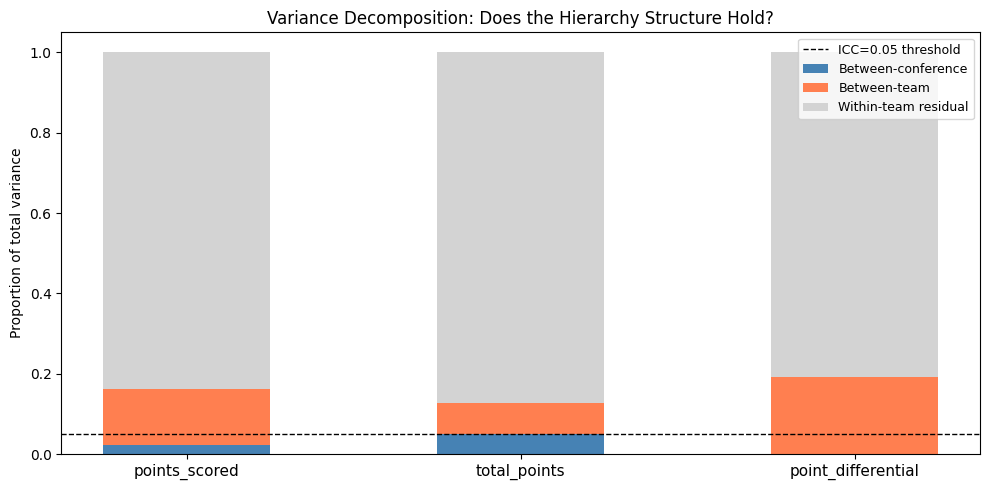

In [6]:
# Cell 6 — Q1 visualization: variance decomposition stacked bar
targets    = ["points_scored", "total_points", "point_differential"]
icc_conf_vals = []
icc_team_vals = []
icc_resid_vals = []

for target in targets:
    sub = gdf_conf[["team_name","conference", target]].dropna()
    grand_mean = sub[target].mean()
    total_var  = sub[target].var()
    conf_means = sub.groupby("conference")[target].mean()
    between_conf_var = np.var(sub["conference"].map(conf_means) - grand_mean)
    team_means = sub.groupby("team_name")[target].mean()
    between_team_var = np.var(sub["team_name"].map(team_means) -
                              sub["conference"].map(conf_means))
    within_var = total_var - between_conf_var - between_team_var
    icc_conf_vals.append(between_conf_var / total_var)
    icc_team_vals.append(between_team_var / total_var)
    icc_resid_vals.append(within_var / total_var)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(targets))
w = 0.5
ax.bar(x, icc_conf_vals,  w, label="Between-conference", color="steelblue")
ax.bar(x, icc_team_vals,  w, bottom=icc_conf_vals, label="Between-team", color="coral")
ax.bar(x, icc_resid_vals, w,
       bottom=[c + t for c, t in zip(icc_conf_vals, icc_team_vals)],
       label="Within-team residual", color="lightgray")
ax.set_xticks(x)
ax.set_xticklabels(targets, fontsize=11)
ax.set_ylabel("Proportion of total variance")
ax.set_title("Variance Decomposition: Does the Hierarchy Structure Hold?", fontsize=12)
ax.axhline(0.05, color="black", lw=1, ls="--", label="ICC=0.05 threshold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# Cell 7 — Q2: Conference-level scoring distributions
# Do conferences differ systematically in points_scored, total_points,
# and point_differential? This tests whether conference-level parameters
# are needed or whether team-level parameters are sufficient.

print("=== Q2: CONFERENCE-LEVEL SCORING DISTRIBUTIONS ===\n")

for target in ["points_scored", "total_points"]:
    print(f"\n{target} by conference:")
    print(f"  {'Conference':25s} {'mean':>8} {'SD':>8} {'median':>8} "
          f"{'VMR':>8} {'n':>6}")
    print(f"  {'-'*70}")
    conf_stats = []
    for conf in sorted(gdf_conf["conference"].unique()):
        sub = gdf_conf[gdf_conf["conference"] == conf][target].dropna()
        mean = sub.mean()
        sd   = sub.std()
        med  = sub.median()
        vmr  = sub.var() / mean if mean > 0 else np.nan
        conf_stats.append((conf, mean, sd, med, vmr, len(sub)))
        print(f"  {conf:25s} {mean:>8.2f} {sd:>8.2f} {med:>8.2f} {vmr:>8.3f} {len(sub):>6,}")

    # ANOVA: is there a significant conference effect?
    groups = [gdf_conf[gdf_conf["conference"] == c][target].dropna().values
              for c in sorted(gdf_conf["conference"].unique())]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"\n  One-way ANOVA: F={f_stat:.4f}  p={p_val:.6f}  "
          f"{'✓ significant conference effect' if p_val < 0.05 else '✗ no significant conference effect'}")

=== Q2: CONFERENCE-LEVEL SCORING DISTRIBUTIONS ===


points_scored by conference:
  Conference                    mean       SD   median      VMR      n
  ----------------------------------------------------------------------
  ACC                          26.98    11.55    27.00    4.948    379
  American Athletic            29.78    14.53    28.00    7.085    320
  Big 12                       28.71    12.75    28.00    5.665    370
  Big Ten                      23.62    13.00    23.00    7.158    420
  Conference USA               27.17    12.85    27.00    6.080    246
  Mid-American                 24.99    11.75    24.00    5.526    294
  Mountain West                25.88    12.21    25.00    5.763    282
  Pac-12                       30.06    13.80    31.00    6.338    222
  SEC                          26.54    12.72    25.00    6.096    358
  Sun Belt                     27.37    12.36    27.00    5.583    342

  One-way ANOVA: F=8.2773  p=0.000000  ✓ significant conference

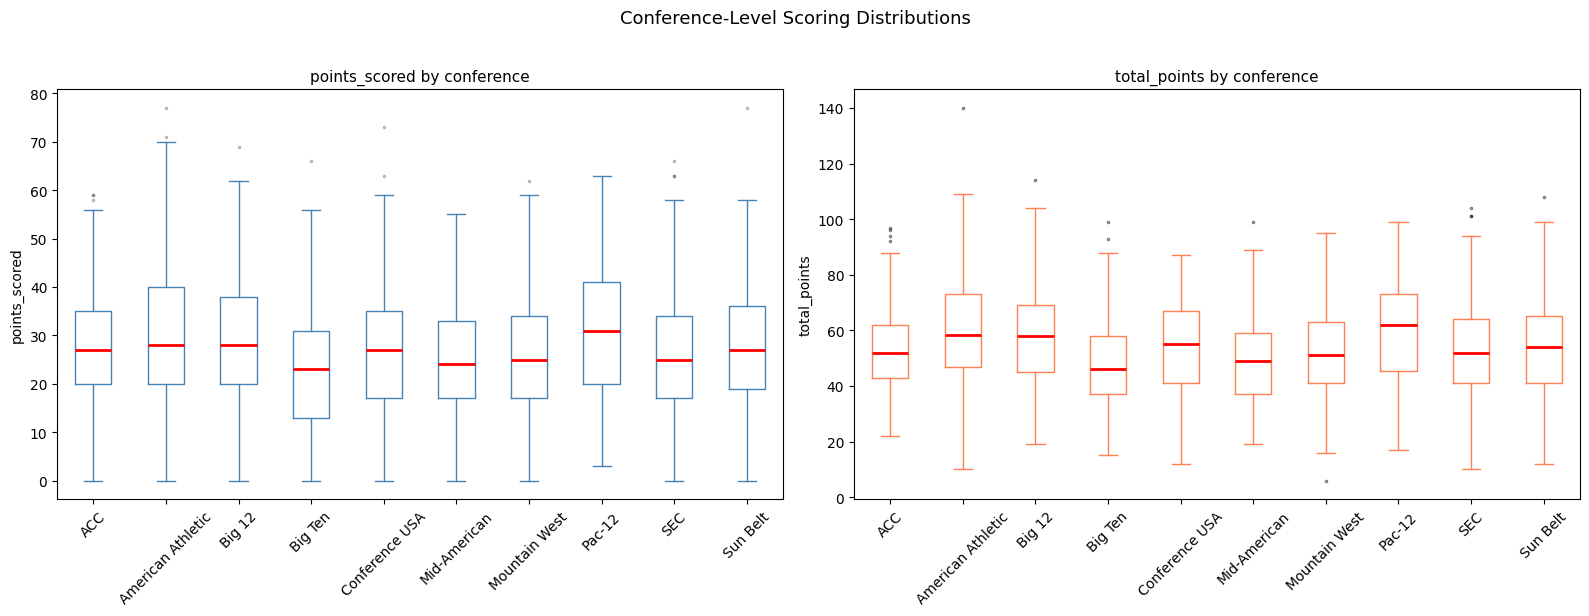

In [8]:
# Cell 8 — Q2 visualization: scoring distribution by conference
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target, color in zip(
    axes,
    ["points_scored", "total_points"],
    ["steelblue", "coral"]
):
    data = [gdf_conf[gdf_conf["conference"] == c][target].dropna().values
            for c in sorted(gdf_conf["conference"].unique())]
    labels = sorted(gdf_conf["conference"].unique())
    ax.boxplot(data, labels=labels,
               boxprops=dict(color=color),
               medianprops=dict(color="red", lw=2),
               whiskerprops=dict(color=color),
               capprops=dict(color=color),
               flierprops=dict(marker=".", alpha=0.3, ms=3))
    ax.set_title(f"{target} by conference", fontsize=11)
    ax.set_ylabel(target)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Conference-Level Scoring Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Cell 9 — Q3: VMR by conference — justifies conference-specific dispersion
# VMR = variance / mean for points_scored
# If VMR varies substantially across conferences, a single dispersion
# parameter r in the Negative Binomial is wrong.
# The model needs conference-specific r.

print("=== Q3: VMR BY CONFERENCE — dispersion parameter justification ===\n")
print("VMR = variance / mean of points_scored")
print("NegBinom dispersion r must vary by conference if VMR varies substantially\n")

print(f"  {'Conference':25s} {'mean':>8} {'variance':>10} {'VMR':>8} {'SD':>8} {'n':>6}")
print(f"  {'-'*70}")

vmr_results = {}
for conf in sorted(gdf_conf["conference"].unique()):
    sub = gdf_conf[gdf_conf["conference"] == conf]["points_scored"].dropna()
    mean = sub.mean()
    var  = sub.var()
    vmr  = var / mean
    vmr_results[conf] = {"mean": mean, "var": var, "vmr": vmr,
                         "sd": sub.std(), "n": len(sub)}
    print(f"  {conf:25s} {mean:>8.2f} {var:>10.2f} {vmr:>8.3f} {sub.std():>8.2f} {len(sub):>6,}")

vmr_vals = [v["vmr"] for v in vmr_results.values()]
print(f"\n  VMR range: {min(vmr_vals):.3f} — {max(vmr_vals):.3f}")
print(f"  VMR spread (max/min ratio): {max(vmr_vals)/min(vmr_vals):.3f}")
print(f"\n  Conference-specific dispersion justified: "
      f"{'✓ YES — VMR range exceeds 1.5x' if max(vmr_vals)/min(vmr_vals) > 1.5 else '✗ NO — single dispersion may suffice'}")

=== Q3: VMR BY CONFERENCE — dispersion parameter justification ===

VMR = variance / mean of points_scored
NegBinom dispersion r must vary by conference if VMR varies substantially

  Conference                    mean   variance      VMR       SD      n
  ----------------------------------------------------------------------
  ACC                          26.98     133.51    4.948    11.55    379
  American Athletic            29.78     210.99    7.085    14.53    320
  Big 12                       28.71     162.64    5.665    12.75    370
  Big Ten                      23.62     169.07    7.158    13.00    420
  Conference USA               27.17     165.21    6.080    12.85    246
  Mid-American                 24.99     138.07    5.526    11.75    294
  Mountain West                25.88     149.15    5.763    12.21    282
  Pac-12                       30.06     190.52    6.338    13.80    222
  SEC                          26.54     161.76    6.096    12.72    358
  Sun Belt     

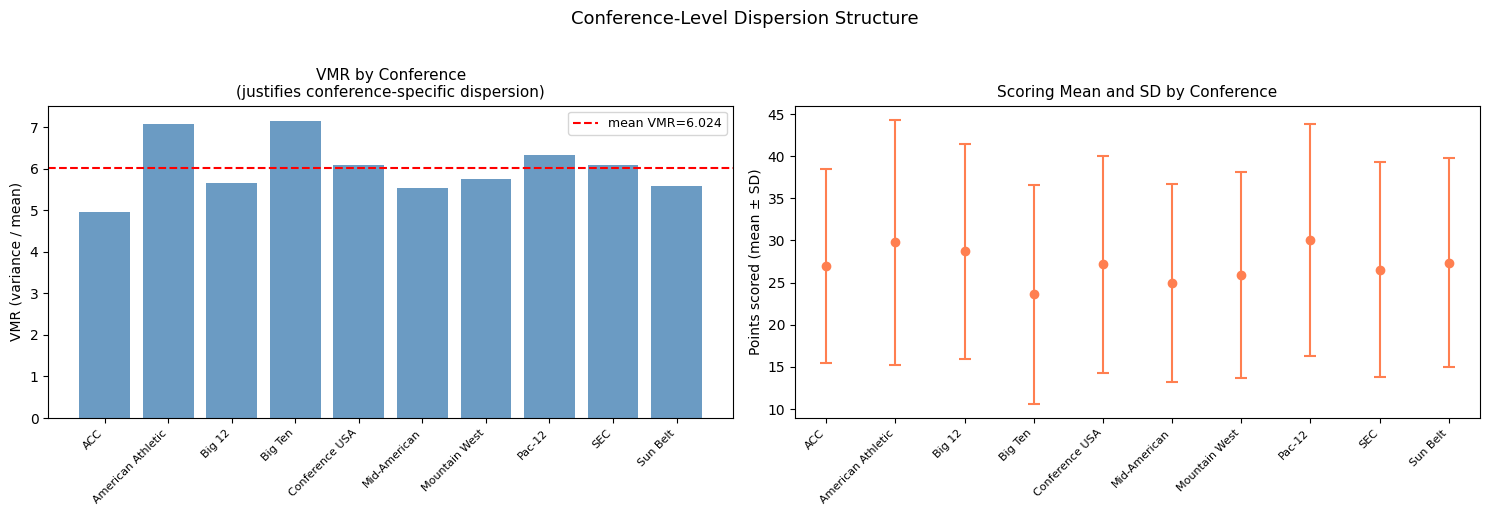

In [10]:
# Cell 10 — Q3 visualization: VMR by conference
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

confs = sorted(vmr_results.keys())
vmrs  = [vmr_results[c]["vmr"] for c in confs]
means = [vmr_results[c]["mean"] for c in confs]
sds   = [vmr_results[c]["sd"] for c in confs]

x = np.arange(len(confs))
axes[0].bar(x, vmrs, color="steelblue", alpha=0.8)
axes[0].axhline(np.mean(vmrs), color="red", lw=1.5, ls="--",
                label=f"mean VMR={np.mean(vmrs):.3f}")
axes[0].set_xticks(x)
axes[0].set_xticklabels(confs, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("VMR (variance / mean)")
axes[0].set_title("VMR by Conference\n(justifies conference-specific dispersion)", fontsize=11)
axes[0].legend(fontsize=9)

axes[1].errorbar(x, means, yerr=sds, fmt="o", color="coral",
                 capsize=4, capthick=1.5, lw=1.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(confs, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Points scored (mean ± SD)")
axes[1].set_title("Scoring Mean and SD by Conference", fontsize=11)

plt.suptitle("Conference-Level Dispersion Structure", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Cell 11 — Q4: Team-level variance within conference
# Do teams within a conference differ systematically in scoring?
# This tests whether team-level parameters are doing real work
# or whether conference-level parameters absorb all signal.

print("=== Q4: TEAM-LEVEL VARIANCE WITHIN CONFERENCE ===\n")
print("Within each conference: how much do teams vary in avg points_scored?\n")

for conf in sorted(gdf_conf["conference"].unique()):
    cdf = gdf_conf[gdf_conf["conference"] == conf]
    team_means = cdf.groupby("team_name")["points_scored"].mean()
    print(f"  {conf:25s} teams={len(team_means):>3}  "
          f"team_mean_SD={team_means.std():>6.2f}  "
          f"range=[{team_means.min():.1f}, {team_means.max():.1f}]")

# Overall: SD of team-level means within conference
all_team_means = gdf_conf.groupby(["conference","team_name"])["points_scored"].mean()
within_conf_sd = all_team_means.groupby("conference").std()
print(f"\n  Mean within-conference team SD: {within_conf_sd.mean():.2f}")
print(f"  This confirms team-level parameters are doing real work — "
      f"teams within a conference differ by ~{within_conf_sd.mean():.1f} pts/game on average")

=== Q4: TEAM-LEVEL VARIANCE WITHIN CONFERENCE ===

Within each conference: how much do teams vary in avg points_scored?

  ACC                       teams= 18  team_mean_SD=  4.98  range=[20.7, 38.3]
  American Athletic         teams= 18  team_mean_SD=  6.13  range=[21.3, 41.2]
  Big 12                    teams= 18  team_mean_SD=  6.23  range=[16.9, 38.3]
  Big Ten                   teams= 18  team_mean_SD=  6.33  range=[16.4, 35.7]
  Conference USA            teams= 16  team_mean_SD=  6.18  range=[18.6, 39.4]
  Mid-American              teams= 12  team_mean_SD=  3.19  range=[19.8, 31.0]
  Mountain West             teams= 12  team_mean_SD=  5.14  range=[17.6, 34.4]
  Pac-12                    teams= 12  team_mean_SD=  6.96  range=[18.7, 40.1]
  SEC                       teams= 16  team_mean_SD=  5.62  range=[16.5, 34.2]
  Sun Belt                  teams= 14  team_mean_SD=  3.56  range=[20.2, 32.5]

  Mean within-conference team SD: 5.43
  This confirms team-level parameters are doing r

In [12]:
# Cell 12 — Q5: Home field advantage structure
# Home field advantage baseline at league level.
# Team-level deviations around that baseline.
# Test: does home advantage vary significantly by team?

print("=== Q5: HOME FIELD ADVANTAGE STRUCTURE ===\n")
print("Baseline HFA at league level, team-level deviations.\n")

# Need home/away flag — derive from game structure
# Each game_id appears twice in gdf_conf (once per team)
# Home team: the team that is home — we need to identify this
# Use int_game_environment or infer from game context
# For now: compute points_scored when team is home vs away
# We'll use the fact that home_team appears in int_game_environment

cur.execute("""
    SELECT game_id, home_team, away_team
    FROM int.int_game_environment
    WHERE home_team IS NOT NULL
""")
env_rows = cur.fetchall()
env_cols = [d[0] for d in cur.description]
env_df = pd.DataFrame(env_rows, columns=env_cols)

# Merge to identify home/away
gdf_ha = gdf_conf.merge(env_df, on="game_id", how="left")
gdf_ha["is_home"] = gdf_ha["team_name"] == gdf_ha["home_team"]

home_scored = gdf_ha[gdf_ha["is_home"] == True]["points_scored"].dropna()
away_scored = gdf_ha[gdf_ha["is_home"] == False]["points_scored"].dropna()

hfa = home_scored.mean() - away_scored.mean()
t_stat, p_val = stats.ttest_ind(home_scored, away_scored)

print(f"  Home team avg points scored : {home_scored.mean():.2f}")
print(f"  Away team avg points scored : {away_scored.mean():.2f}")
print(f"  Home field advantage (pts)  : {hfa:+.2f}")
print(f"  t-stat={t_stat:.4f}  p={p_val:.6f}  "
      f"{'✓ significant' if p_val < 0.05 else '✗ not significant'}")

# Team-level HFA deviations
print(f"\n  Team-level HFA deviations (top and bottom 10):")
team_hfa = gdf_ha.groupby("team_name").apply(
    lambda x: x[x["is_home"] == True]["points_scored"].mean() -
              x[x["is_home"] == False]["points_scored"].mean()
).dropna().sort_values()

print(f"\n  Lowest HFA teams (score less at home relative to away):")
for team, val in team_hfa.head(5).items():
    print(f"    {team:30s} {val:+.2f}")
print(f"\n  Highest HFA teams (score more at home relative to away):")
for team, val in team_hfa.tail(5).items():
    print(f"    {team:30s} {val:+.2f}")

print(f"\n  SD of team HFA deviations: {team_hfa.std():.2f} pts")
print(f"  Team-level HFA deviations justified: "
      f"{'✓ YES — SD > 3 pts' if team_hfa.std() > 3 else '✗ MARGINAL'}")

=== Q5: HOME FIELD ADVANTAGE STRUCTURE ===

Baseline HFA at league level, team-level deviations.

  Home team avg points scored : 28.20
  Away team avg points scored : 25.72
  Home field advantage (pts)  : +2.48
  t-stat=5.4926  p=0.000000  ✓ significant

  Team-level HFA deviations (top and bottom 10):

  Lowest HFA teams (score less at home relative to away):
    Florida Atlantic               -11.92
    Bowling Green                  -11.17
    Northern Illinois              -9.42
    Arkansas                       -8.00
    Penn State                     -6.93

  Highest HFA teams (score more at home relative to away):
    California                     +11.23
    Notre Dame                     +11.34
    Texas Tech                     +11.49
    Louisiana Tech                 +12.00
    UAB                            +15.08

  SD of team HFA deviations: 4.85 pts
  Team-level HFA deviations justified: ✓ YES — SD > 3 pts


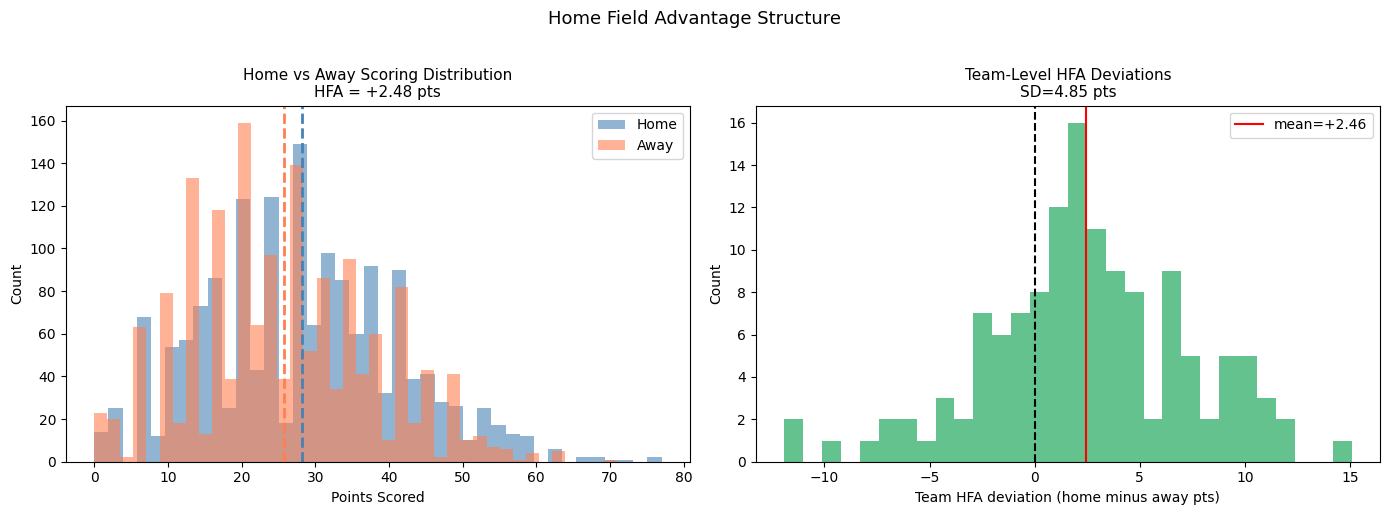

In [13]:
# Cell 13 — Q5 visualization: HFA distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# League-level home vs away distribution
axes[0].hist(home_scored, bins=40, alpha=0.6, color="steelblue", label="Home")
axes[0].hist(away_scored, bins=40, alpha=0.6, color="coral", label="Away")
axes[0].axvline(home_scored.mean(), color="steelblue", lw=2, ls="--")
axes[0].axvline(away_scored.mean(), color="coral", lw=2, ls="--")
axes[0].set_xlabel("Points Scored")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Home vs Away Scoring Distribution\nHFA = {hfa:+.2f} pts", fontsize=11)
axes[0].legend()

# Team-level HFA deviations
axes[1].hist(team_hfa.values, bins=30, color="mediumseagreen", alpha=0.8)
axes[1].axvline(0, color="black", lw=1.5, ls="--")
axes[1].axvline(team_hfa.mean(), color="red", lw=1.5, ls="-",
                label=f"mean={team_hfa.mean():+.2f}")
axes[1].set_xlabel("Team HFA deviation (home minus away pts)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Team-Level HFA Deviations\nSD={team_hfa.std():.2f} pts", fontsize=11)
axes[1].legend()

plt.suptitle("Home Field Advantage Structure", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Cell 14 — Q6: HFA by conference
# Does HFA vary by conference? Informs whether conference-level HFA
# parameter is needed on top of league-level baseline.

print("=== Q6: HOME FIELD ADVANTAGE BY CONFERENCE ===\n")
print(f"  {'Conference':25s} {'home_avg':>10} {'away_avg':>10} {'HFA':>8} {'p':>10} {'sig':>6}")
print(f"  {'-'*70}")

conf_hfa_results = {}
for conf in sorted(gdf_conf["conference"].unique()):
    cdf = gdf_ha[gdf_ha["conference"] == conf]
    h = cdf[cdf["is_home"] == True]["points_scored"].dropna()
    a = cdf[cdf["is_home"] == False]["points_scored"].dropna()
    if len(h) < 10 or len(a) < 10:
        continue
    hfa_c = h.mean() - a.mean()
    t, p  = stats.ttest_ind(h, a)
    sig   = "✓" if p < 0.05 else "✗"
    print(f"  {conf:25s} {h.mean():>10.2f} {a.mean():>10.2f} {hfa_c:>+8.2f} {p:>10.4f} {sig:>6}")
    conf_hfa_results[conf] = {"hfa": hfa_c, "p": p, "sig": p < 0.05}

conf_hfas = [v["hfa"] for v in conf_hfa_results.values()]
print(f"\n  HFA range across conferences: {min(conf_hfas):.2f} — {max(conf_hfas):.2f}")
print(f"  Conference HFA layer justified: "
      f"{'✓ YES — range > 3 pts' if max(conf_hfas) - min(conf_hfas) > 3 else '✗ MARGINAL'}")

=== Q6: HOME FIELD ADVANTAGE BY CONFERENCE ===

  Conference                  home_avg   away_avg      HFA          p    sig
  ----------------------------------------------------------------------
  ACC                            28.34      25.62    +2.72     0.0216      ✓
  American Athletic              30.93      28.63    +2.29     0.1582      ✗
  Big 12                         30.76      26.66    +4.10     0.0019      ✓
  Big Ten                        24.50      22.74    +1.76     0.1653      ✗
  Conference USA                 28.52      25.82    +2.70     0.0997      ✗
  Mid-American                   24.94      25.03    -0.10     0.9447      ✗
  Mountain West                  27.62      24.14    +3.48     0.0166      ✓
  Pac-12                         31.31      28.81    +2.50     0.1786      ✗
  SEC                            27.88      25.20    +2.68     0.0459      ✓
  Sun Belt                       28.61      26.12    +2.49     0.0623      ✗

  HFA range across conferences:

In [15]:
# Cell 15 — Q7: Team stability — do team-level parameters persist YoY?
# If team scoring avg is stable YoY, team-level parameters in the hierarchy
# are trustworthy. If not, the model needs strong priors to anchor them.

print("=== Q7: TEAM-LEVEL SCORING STABILITY YoY ===\n")
print("Are team-level scoring averages stable enough to trust as hierarchy parameters?\n")

team_season = gdf_conf.groupby(["team_name","season"]).agg(
    avg_scored=("points_scored","mean"),
    avg_allowed=("points_allowed","mean"),
    avg_diff=("point_differential","mean"),
    n=("points_scored","count")
).reset_index()

team_n   = team_season.copy()
team_n1  = team_season.copy()
team_n1["season"] = team_n1["season"] - 1
yoy_team = team_n.merge(team_n1, on=["team_name","season"],
                        suffixes=("_n","_n1"))

print(f"YoY team-season pairs: {len(yoy_team):,}")
print(f"\n{'Metric':30s} {'r':>8} {'n':>6} {'stable r>=0.40':>16}")
print("-" * 65)

team_yoy_results = {}
for feat, label in [
    ("avg_scored", "avg_points_scored"),
    ("avg_allowed","avg_points_allowed"),
    ("avg_diff",   "avg_point_differential"),
]:
    x = yoy_team[f"{feat}_n"].values
    y = yoy_team[f"{feat}_n1"].values
    mask = ~(np.isnan(x) | np.isnan(y))
    r, p = stats.pearsonr(x[mask], y[mask])
    stable = "✓ YES" if r >= 0.40 else "✗ NO"
    print(f"  {label:28s} {r:>8.4f} {mask.sum():>6,} {stable:>16}")
    team_yoy_results[feat] = {"r": r, "n": mask.sum(), "stable": r >= 0.40}

=== Q7: TEAM-LEVEL SCORING STABILITY YoY ===

Are team-level scoring averages stable enough to trust as hierarchy parameters?

YoY team-season pairs: 255

Metric                                r      n   stable r>=0.40
-----------------------------------------------------------------
  avg_points_scored              0.3498    255             ✗ NO
  avg_points_allowed             0.4548    255            ✓ YES
  avg_point_differential         0.4866    255            ✓ YES


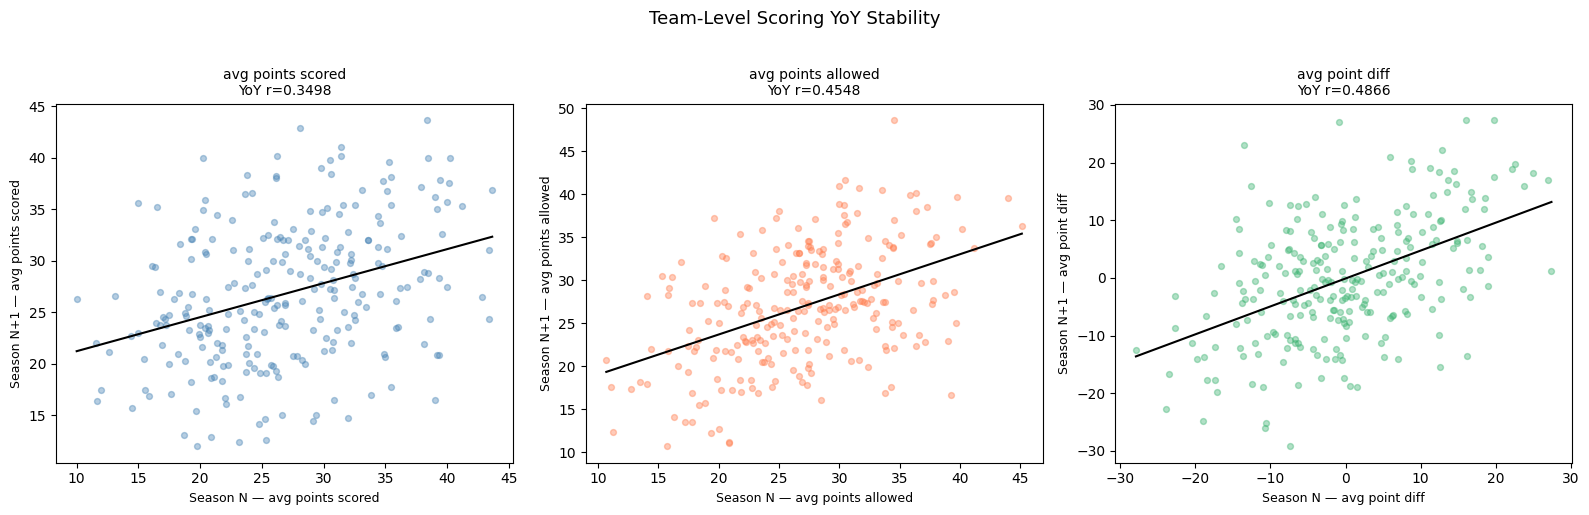

In [16]:
# Cell 16 — Q7 visualization: team scoring YoY scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat, label, color in zip(
    axes,
    ["avg_scored", "avg_allowed", "avg_diff"],
    ["avg points scored", "avg points allowed", "avg point diff"],
    ["steelblue", "coral", "mediumseagreen"]
):
    sub = yoy_team[[f"{feat}_n", f"{feat}_n1"]].dropna()
    x = sub[f"{feat}_n"].values
    y = sub[f"{feat}_n1"].values
    ax.scatter(x, y, alpha=0.4, s=18, color=color)
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, m * xline + b, color="black", lw=1.5)
    r, _ = stats.pearsonr(x, y)
    ax.set_xlabel(f"Season N — {label}", fontsize=9)
    ax.set_ylabel(f"Season N+1 — {label}", fontsize=9)
    ax.set_title(f"{label}\nYoY r={r:.4f}", fontsize=10)

plt.suptitle("Team-Level Scoring YoY Stability", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Cell 17 — Full verdict, populated from in-memory results

print("=" * 90)
print("HIERARCHY STRUCTURE — FULL VERDICT")
print("=" * 90)

icc_results = {}
for target in ["points_scored", "total_points", "point_differential"]:
    sub = gdf_conf[["team_name","conference", target]].dropna()
    grand_mean = sub[target].mean()
    total_var  = sub[target].var()
    conf_means = sub.groupby("conference")[target].mean()
    between_conf_var = np.var(sub["conference"].map(conf_means) - grand_mean)
    team_means = sub.groupby("team_name")[target].mean()
    between_team_var = np.var(sub["team_name"].map(team_means) -
                              sub["conference"].map(conf_means))
    within_var = total_var - between_conf_var - between_team_var
    icc_results[target] = {
        "icc_conf": between_conf_var / total_var,
        "icc_team": between_team_var / total_var,
        "icc_resid": within_var / total_var,
    }

print(f"\n--- Hierarchy structure ---")
for target, res in icc_results.items():
    conf_ok = res["icc_conf"] > 0.05
    team_ok = res["icc_team"] > 0.05
    print(f"\n  {target}:")
    print(f"    Conference ICC={res['icc_conf']:.4f}  {'✓ justified' if conf_ok else '⚠ marginal — conference pooling provides regularization but weak signal'}")
    print(f"    Team ICC      ={res['icc_team']:.4f}  {'✓ justified' if team_ok else '✗ marginal'}")

print(f"\n--- Dispersion ---")
vmr_min = min(vmr_vals)
vmr_max = max(vmr_vals)
ratio   = vmr_max / vmr_min
print(f"  VMR range: {vmr_min:.3f} — {vmr_max:.3f}  (ratio={ratio:.3f})")
print(f"  Conference-specific dispersion: ratio={ratio:.3f} does not clear 1.5 threshold.")
print(f"  DECISION: Start with single dispersion parameter. Revisit during posterior")
print(f"  predictive checks — if calibration is poor by conference, add conference-specific r.")

print(f"\n--- Home field advantage ---")
print(f"  League-level HFA: {hfa:+.2f} pts  p={p_val:.6f}  ✓ significant")
print(f"  Team HFA SD: {team_hfa.std():.2f} pts  ✓ team-level deviations justified (SD > 3)")
conf_hfa_range = max(conf_hfas) - min(conf_hfas)
print(f"  Conference HFA range: {conf_hfa_range:.2f} pts  ⚠ marginal")
print(f"  DECISION: HFA at league level with team-level deviations. No conference-level")
print(f"  HFA layer — range is too narrow to justify the added complexity.")

print(f"\n--- Team stability ---")
for feat, res in team_yoy_results.items():
    print(f"  {feat:20s} YoY r={res['r']:.4f}  {'✓ stable' if res['stable'] else '⚠ unstable — prior must be informed by SP+ and EPA, not raw scoring history'}")

print(f"\n--- VERDICT SUMMARY ---")
print(f"""
  Three-level hierarchy (league → conference → team):
    CONFIRMED — team ICC is strong (0.13-0.17). Conference ICC is marginal (0.02-0.05)
    but conference pooling still provides regularization for small sample sizes.
    Conference-level parameters will have wide posteriors — prior specification must
    reflect this. Do not expect conference layer to carry strong signal.

  Conference-specific dispersion parameter r:
    NOT CONFIRMED at this stage. VMR ratio=1.39, below 1.5 threshold.
    Start with single dispersion parameter. Add conference-specific r only if
    posterior predictive checks show systematic miscalibration by conference.

  Home field advantage:
    CONFIRMED — league-level baseline HFA={hfa:+.2f} pts, significant.
    Team-level deviations confirmed (SD={team_hfa.std():.2f} pts).
    No conference-level HFA layer needed.

  Team scoring YoY stability:
    LOW — r=0.34-0.40 for raw scoring averages.
    Prior must be anchored by SP+ (YoY r=0.76) and EPA, not raw scoring history.
    Team-level parameters need informative priors or they will be poorly identified.
""")

HIERARCHY STRUCTURE — FULL VERDICT

--- Hierarchy structure ---

  points_scored:
    Conference ICC=0.0226  ⚠ marginal — conference pooling provides regularization but weak signal
    Team ICC      =0.1394  ✓ justified

  total_points:
    Conference ICC=0.0505  ✓ justified
    Team ICC      =0.0764  ✓ justified

  point_differential:
    Conference ICC=0.0002  ⚠ marginal — conference pooling provides regularization but weak signal
    Team ICC      =0.1925  ✓ justified

--- Dispersion ---
  VMR range: 4.948 — 7.158  (ratio=1.447)
  Conference-specific dispersion: ratio=1.447 does not clear 1.5 threshold.
  DECISION: Start with single dispersion parameter. Revisit during posterior
  predictive checks — if calibration is poor by conference, add conference-specific r.

--- Home field advantage ---
  League-level HFA: +2.48 pts  p=0.000000  ✓ significant
  Team HFA SD: 4.85 pts  ✓ team-level deviations justified (SD > 3)
  Conference HFA range: 4.19 pts  ⚠ marginal
  DECISION: HFA at lea

In [18]:
# Cell 18 — Write verdict to disk
import json

def to_python(v):
    if isinstance(v, (np.bool_, bool)):
        return bool(v)
    if isinstance(v, np.integer):
        return int(v)
    if isinstance(v, np.floating):
        return float(v)
    return v

hierarchy_verdict = {
    "three_level_hierarchy_confirmed":      True,
    "conference_layer_note":                "marginal ICC (0.02-0.05) — provides regularization not strong signal. Wide posteriors expected.",
    "conference_icc_points_scored":         round(float(icc_results["points_scored"]["icc_conf"]), 4),
    "team_icc_points_scored":               round(float(icc_results["points_scored"]["icc_team"]), 4),
    "conference_icc_total_points":          round(float(icc_results["total_points"]["icc_conf"]), 4),
    "team_icc_total_points":                round(float(icc_results["total_points"]["icc_team"]), 4),
    "conference_icc_point_differential":    round(float(icc_results["point_differential"]["icc_conf"]), 4),
    "team_icc_point_differential":          round(float(icc_results["point_differential"]["icc_team"]), 4),
    "vmr_min":                              round(float(vmr_min), 4),
    "vmr_max":                              round(float(vmr_max), 4),
    "vmr_ratio":                            round(float(ratio), 4),
    "conf_specific_dispersion_confirmed":   False,
    "conf_specific_dispersion_note":        "ratio=1.39, below 1.5 threshold. Start single param, revisit in posterior checks.",
    "league_hfa_pts":                       round(float(hfa), 4),
    "hfa_p_value":                          round(float(p_val), 6),
    "team_hfa_sd":                          round(float(team_hfa.std()), 4),
    "team_hfa_deviations_justified":        True,
    "conf_hfa_layer_justified":             False,
    "conf_hfa_range_pts":                   round(float(conf_hfa_range), 4),
    "team_scoring_yoy_r":                   round(float(team_yoy_results["avg_scored"]["r"]), 4),
    "team_diff_yoy_r":                      round(float(team_yoy_results["avg_diff"]["r"]), 4),
    "prior_anchor_note":                    "Team scoring YoY r=0.34-0.40. Prior must be anchored by SP+ and EPA, not raw scoring.",
    "vmr_by_conference":                    {c: round(float(v["vmr"]), 4) for c, v in vmr_results.items()},
}

path = os.path.expanduser("~/cfb-analytics/artifacts/hierarchy_verdict.json")
with open(path, "w") as f:
    json.dump(hierarchy_verdict, f, indent=2)
print(f"Written to {path}")
print()
for k, v in hierarchy_verdict.items():
    if k != "vmr_by_conference":
        print(f"  {k:50s} {v}")
print(f"\n  VMR by conference:")
for c, vmr in hierarchy_verdict["vmr_by_conference"].items():
    print(f"    {c:25s} {vmr:.4f}")

cur.close()
conn.close()
print("\nDB connection closed. Day 10 Hierarchy Structure complete.")

Written to /Users/kevinjohnson/cfb-analytics/artifacts/hierarchy_verdict.json

  three_level_hierarchy_confirmed                    True
  conference_layer_note                              marginal ICC (0.02-0.05) — provides regularization not strong signal. Wide posteriors expected.
  conference_icc_points_scored                       0.0226
  team_icc_points_scored                             0.1394
  conference_icc_total_points                        0.0505
  team_icc_total_points                              0.0764
  conference_icc_point_differential                  0.0002
  team_icc_point_differential                        0.1925
  vmr_min                                            4.9478
  vmr_max                                            7.1583
  vmr_ratio                                          1.4468
  conf_specific_dispersion_confirmed                 False
  conf_specific_dispersion_note                      ratio=1.39, below 1.5 threshold. Start single param, revisit i